# Power Consumption Analysis - Containerised 5G Deployment

This notebook analyses power consumption measurements collected from a containerised 5G testbed
using srsRAN and Open5GS. Four topologies are compared: 1CU-1DU, 1CU-2DU, 1CU-3DU, and 1CU-4DU.

The analysis is structured in two parts:
1. Per-component power breakdown (CU-CP, CU-UP, per DU) at baseline load for each topology
2. Power consumption scaling across varying CQI values (5, 10, 15) and UE counts (1, 4, 16, 64, 96)

## 1. Per-Component Power Breakdown

Breakdown measurements were collected using Scaphandre (60 samples, 5s interval) with the system
at thermal steady state (CPU cores below 35°C). One representative run per topology is used.

In [2]:
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

LOGS_DIR = "/home/martafra/Desktop/dissertation/docs/logs"

BREAKDOWN_FILES = {
    '1cu1du': f"{LOGS_DIR}/breakdown_1cu1du_20260510_071356.csv",
    '1cu2du': f"{LOGS_DIR}/breakdown_1cu2du_20260510_121914.csv",
    '1cu3du': f"{LOGS_DIR}/breakdown_1cu3du_20260510_125725.csv",
    '1cu4du': f"{LOGS_DIR}/breakdown_1cu4du_20260510_161647.csv",
}

dfs = []
for topo, path in BREAKDOWN_FILES.items():
    df = pd.read_csv(path)
    df['topology'] = topo
    dfs.append(df)

breakdown = pd.concat(dfs, ignore_index=True)
print(f"Total rows: {breakdown.shape[0]}")
print(f"Components: {sorted(breakdown['component'].unique())}")
breakdown.head()

Total rows: 1080
Components: ['cu_cp', 'cu_up', 'du1', 'du2', 'du3', 'du4']


,timestamp,component,pid,microwatts,watts,topology
0,2026-05-10T06:13:56,cu_cp,9877,4.836587e+05,0.483659,1cu1du
1,2026-05-10T06:13:56,cu_up,10063,4.836587e+05,0.483659,1cu1du
2,2026-05-10T06:13:56,du1,10104,6.477855e+06,6.477855,1cu1du
3,2026-05-10T06:14:01,cu_cp,9877,4.952078e+05,0.495208,1cu1du
4,2026-05-10T06:14:01,cu_up,10063,5.033259e+05,0.503326,1cu1du


Data loaded successfully: 1080 rows across 4 topologies. Each row represents one sample
for one component. Components present: CU-CP, CU-UP, DU1, DU2, DU3, DU4 (not all present
in all topologies). The `watts` column is used for all subsequent analysis.

In [3]:
summary_breakdown = (
    breakdown
    .groupby(['topology', 'component'])['watts']
    .agg(mean_W='mean', std_W='std', n='count')
    .reset_index()
)
print(summary_breakdown.to_string())

   topology component     mean_W     std_W   n
0    1cu1du     cu_cp   0.493841  0.007091  60
1    1cu1du     cu_up   0.496046  0.008365  60
2    1cu1du       du1   6.662034  0.057416  60
3    1cu2du     cu_cp   0.921738  0.012195  60
4    1cu2du     cu_up   0.912357  0.012032  60
5    1cu2du       du1  12.113689  0.252460  60
6    1cu2du       du2  12.099023  0.269338  60
7    1cu3du     cu_cp   0.680435  0.037773  60
8    1cu3du     cu_up   0.674839  0.038657  60
9    1cu3du       du1  12.421715  0.501755  60
10   1cu3du       du2  12.388885  0.494618  60
11   1cu3du       du3  12.409882  0.494936  60
12   1cu4du     cu_cp   0.409480  0.029764  60
13   1cu4du     cu_up   0.415763  0.029109  60
14   1cu4du       du1  13.135969  0.527910  60
15   1cu4du       du2  13.159880  0.538750  60
16   1cu4du       du3  13.156208  0.523007  60
17   1cu4du       du4  13.133410  0.518555  60


Each topology shows consistent per-DU power values with low standard deviation,
confirming measurement stability. DU power dominates in all topologies. CU-CP and
CU-UP remain below 1W across all configurations.

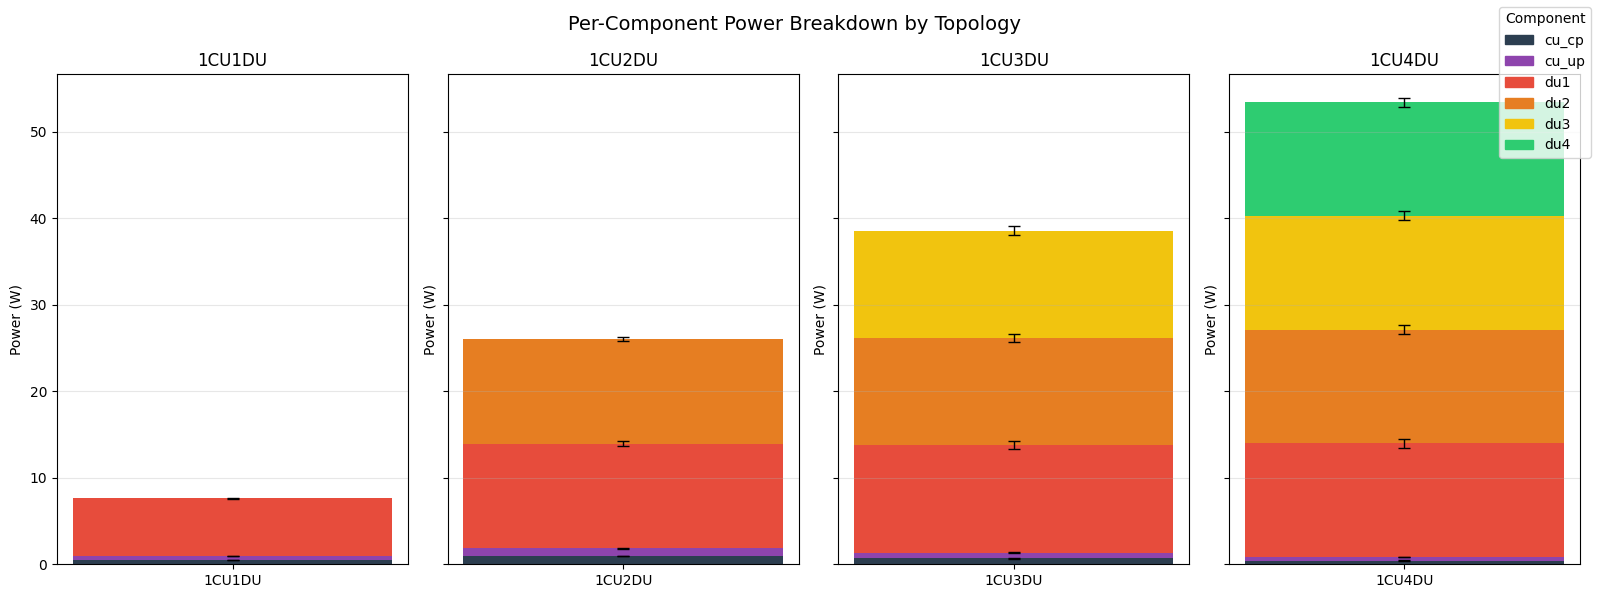

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 6), sharey=True)
topologies = ['1cu1du', '1cu2du', '1cu3du', '1cu4du']
components_order = ['cu_cp', 'cu_up', 'du1', 'du2', 'du3', 'du4']
colors = {
    'cu_cp': '#2c3e50',
    'cu_up': '#8e44ad',
    'du1':   '#e74c3c',
    'du2':   '#e67e22',
    'du3':   '#f1c40f',
    'du4':   '#2ecc71'
}

for ax, topo in zip(axes, topologies):
    subset = summary_breakdown[summary_breakdown['topology'] == topo]
    subset = subset.set_index('component').reindex(
        [c for c in components_order if c in subset['component'].values]
    ).reset_index()
    
    bottom = 0
    for _, row in subset.iterrows():
        ax.bar(
            topo.upper(), row['mean_W'],
            bottom=bottom,
            color=colors[row['component']],
            label=row['component'],
            yerr=row['std_W'],
            error_kw={'capsize': 4, 'elinewidth': 1},
        )
        bottom += row['mean_W']
    
    ax.set_title(topo.upper())
    ax.set_ylabel('Power (W)')
    ax.grid(True, alpha=0.3, axis='y')

present_components = [c for c in components_order if c in summary_breakdown['component'].values]
handles = [plt.Rectangle((0,0),1,1, color=colors[c]) for c in present_components]
fig.legend(handles, present_components, loc='upper right', title='Component')
plt.suptitle('Per-Component Power Breakdown by Topology', fontsize=14)
plt.tight_layout()
plt.savefig('../analysis/breakdown_stacked.png', dpi=150)
plt.show()

DU processing accounts for the dominant share of total RAN power across all topologies.
CU-CP and CU-UP together contribute less than 2W in all cases, confirming that the control
plane overhead is negligible relative to the distributed units. Per-DU power increases
slightly with the number of DUs, from 6.7W in 1CU-1DU to 13.1W in 1CU-4DU, suggesting
that each additional DU places a higher processing demand on the shared CPU resources.